In [1]:
#%pip install opencv-python --break-system-packages
#%pip install matplotlib --break-system-packages
#%pip install --upgrade numpy opencv-python matplotlib --break-system-packages
#%pip install pandas --break-system-packages

# Projet de Traitement d'Image : WLS Filter

Ce notebook documente notre implémentation et nos expérimentations autour du filtre **WLS (Weighted Least Squares)**, basé sur l'article de référence *"Edge-Preserving Decompositions for Multi-Scale Tone and Detail Manipulation"* (Farbman et al.). 

L'objectif est d'explorer les propriétés de ce filtre global pour la décomposition d'image en couches de détails, la manipulation multi-échelle et enfin son application pratique dans un exemple de stylisation.

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import cv2

%load_ext autoreload
%autoreload 2
import toolbox

## --- PARTIE I : Test et Validation des Gradients ---

---

Cette section permet de valider la précision des gradients calculés manuellement ($dx$ et $dy$) en les comparant aux versions de référence.

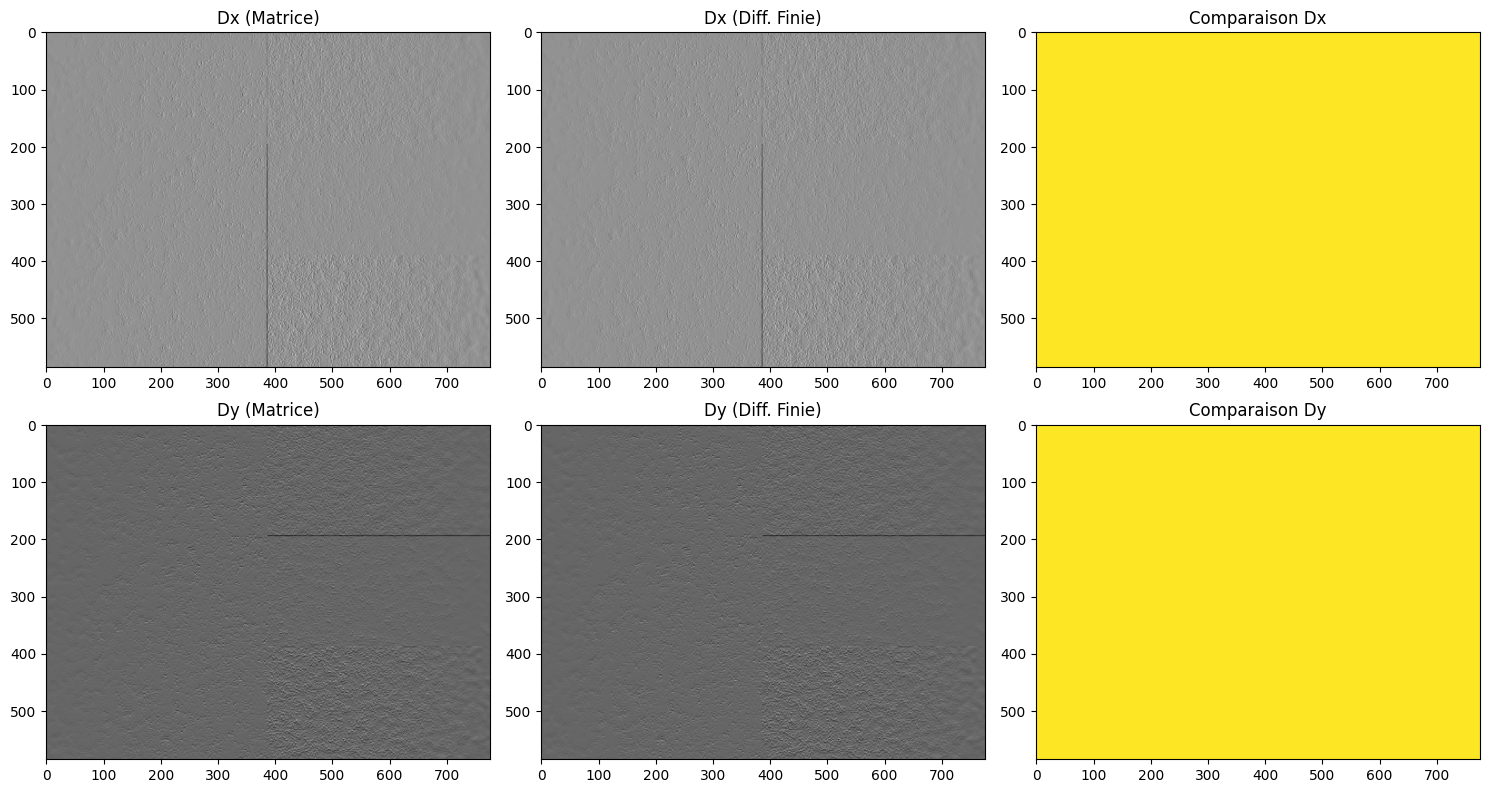

In [3]:
img_bgr = cv2.imread("photo_de_test.png")

Dx, Dy = toolbox.build_Dx_Dy(img_bgr)
toolbox.comparer_gradients(img_bgr, Dx, Dy)

## --- PARTIE II : Implémentation du Filtre WLS ---

Le cœur de l'algorithme WLS consiste à trouver une image lissée $u$ qui minimise la fonction d'énergie suivante pour une image d'entrée $g$ :

$$\sum_{p} \left( (u_p - g_p)^2 + \lambda \left( a_{x,p}(g) \left(\frac{\partial u}{\partial x}\right)_p^2 + a_{y,p}(g) \left(\frac{\partial u}{\partial y}\right)_p^2 \right) \right)$$

Où :
* $\lambda$ (lambda) contrôle la balance globale entre la fidélité à l'image originale et le lissage.
* $\alpha$ (alpha) détermine la sensibilité du filtre aux gradients de l'image. Un $\alpha$ élevé empêche le lissage de traverser les contours nets.

 **Validation :** Nous testons ici l'algorithme sur la version en niveaux de gris de notre image pour valider le comportement du solveur linéaire creux (`spsolve`). Les images réelles étant en couleur, nous étendons notre fonction WLS aux trois canaux (Rouge, Vert, Bleu). Afin de maintenir une cohérence stricte des contours et d'éviter les dérives chromatiques ou les artefacts aux frontières, la matrice de lissage (les poids $a_x$ et $a_y$) est calculée **une seule fois sur la luminance globale**, puis appliquée uniformément sur chaque canal RGB de manière indépendante.

In [4]:
img_test_rgb = data.cat()
img_test_rgb = img_test_rgb.astype(np.float32)/255.0
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

Dx = Dx.tocsr()
Dy = Dy.tocsr()

In [5]:
img_lisse_RGB = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=2)

In [6]:
img_lisse_gray = toolbox.WLS_gray(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=2)

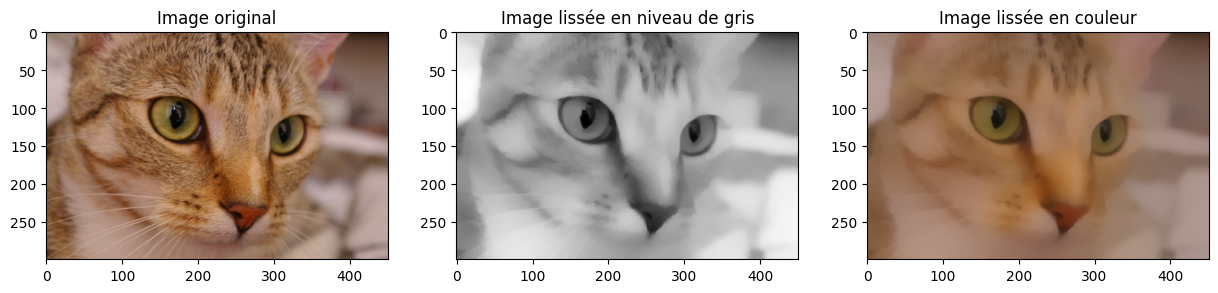

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes[0].imshow(img_test_rgb, cmap='gray')
axes[1].imshow(img_lisse_gray, cmap='gray')
axes[2].imshow(img_lisse_RGB)
axes[0].set_title("Image original")
axes[1].set_title("Image lissée en niveau de gris")
axes[2].set_title("Image lissée en couleur")
plt.show()

## --- PARTIE III : Test des méthodes de lissage itérative et récurcive, Comparaison avec le Filtre Bilatéral ---

Dans cette section, nous explorons l'implémentation et le comportement de différentes approches de filtrage pour le lissage préservant les contours. L'enjeu est de nettoyer ou de simplifier l'image tout en maintenant la netteté des frontières géométriques.

In [20]:
img_test_rgb = data.cat()
img_test_rgb = img_test_rgb.astype(np.float32)/255.0
n, m, c = img_test_rgb.shape
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

Dx = Dx.tocsr()
Dy = Dy.tocsr()

In [21]:
# Lissage itératif
list_lambda = np.linspace(0.5,10,4)
img_lisse_RGB = np.zeros((n,m,c,4))
for i in range(len(list_lambda)):
    img_lisse_RGB[:,:,:,i] = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=list_lambda[i])
    a = 1


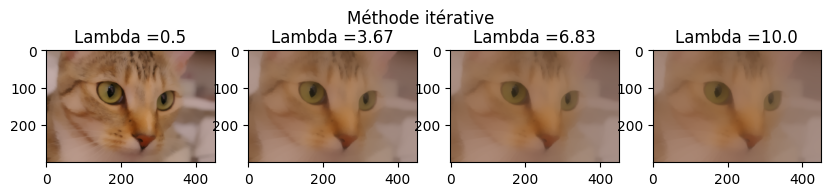

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2))
axes = axes.flatten()

for i in range(4):
    axes[i].set_title("Lambda ="+str(round(list_lambda[i], 2)))
    axes[i].imshow(img_lisse_RGB[:,:,:,i])
fig.suptitle("Méthode itérative")
plt.show()

In [11]:
# Lissage Récursif
list_lambda = np.linspace(1,2,4)
img_lisse_RGB = np.zeros((n,m,c,4))
img_lisse_RGB[:,:,:,0] = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=1)

for i in range(len(list_lambda)-1):
    img_intermediaire = img_lisse_RGB[:,:,:,i].copy().astype(np.float32)
    img_lisse_RGB[:,:,:,i+1] = toolbox.WLS_RGB(img_intermediaire, Dx, Dy, alpha=1.2, eps=1e-4, lamb=list_lambda[i])

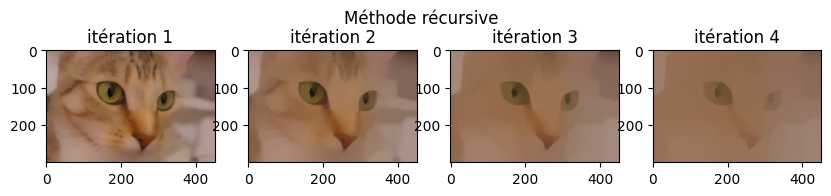

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2))
axes = axes.flatten()

for i in range(4):
    axes[i].set_title("itération "+str(i+1))
    axes[i].imshow(img_lisse_RGB[:,:,:,i])
fig.suptitle("Méthode récursive")
plt.show()

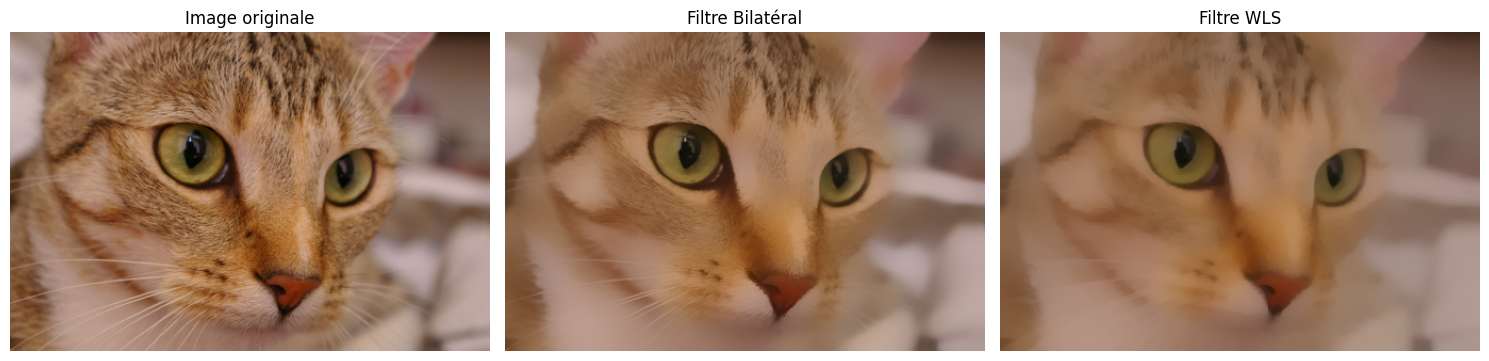

In [13]:
# --- AFFICHAGE COMPARAISON WLS - BILATERAL ---

# 1. Calcul WLS RGB
img_wls = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=1.5)

# 2. Calcul Bilatéral
# On ajuste sigma_color (0.15) pour qu'il ait un lissage visuellement similaire au WLS
img_bila = cv2.bilateralFilter(img_test_rgb, d=30, sigmaColor=0.3, sigmaSpace=30)

# 3. Affichage
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_test_rgb, vmin=0, vmax=1)
plt.title("Image originale")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_bila, vmin=0, vmax=1)
plt.title("Filtre Bilatéral")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_wls, vmin=0, vmax=1)
plt.title("Filtre WLS")
plt.axis('off')

plt.tight_layout()
plt.show()

## --- PARTIE IV :  Multi-scale edge-preserving decompositions ---

Une application classique des filtres préservant les contours est la **stylisation d'image**. Le traitement se déroule en deux étapes indépendantes avant d'être fusionné :

1. **Abstraction des couleurs :** Nous utilisons la base fortement lissée du filtre WLS (`base_rec`). Comme le filtre supprime les textures (bruit, micro-détails) mais préserve la netteté des transitions géométriques, l'image prend un aspect de peinture ou d'affiche aplatie.
2. **Extraction des lignes de structure :** En parallèle, nous appliquons un détecteur de contours (algorithme de Canny assisté d'un flou Gaussien) pour générer un masque de traits noirs nets.

**Rendu :** En superposition, les contours noirs viennent souligner l'image aux aplats de couleurs pour simuler l'esthétique d'une bande dessinée. 

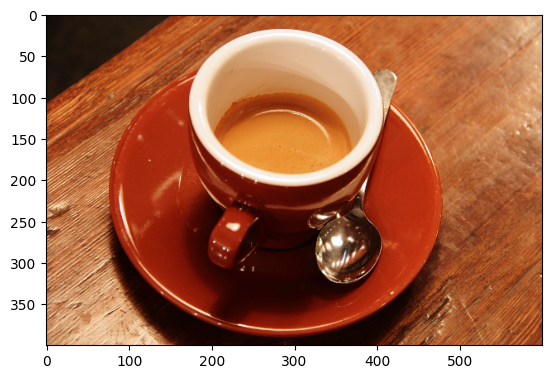

In [14]:
image = data.coffee()
image = image.astype(np.float32)/255.0

plt.imshow(image)
plt.show()

In [15]:
# Méthode Récursive
base_rec, coarse_rec, medium_rec, fine_rec = toolbox.Tone_Mapping_rec(image)

Text(0.5, 0.98, 'Méthode Récursive')

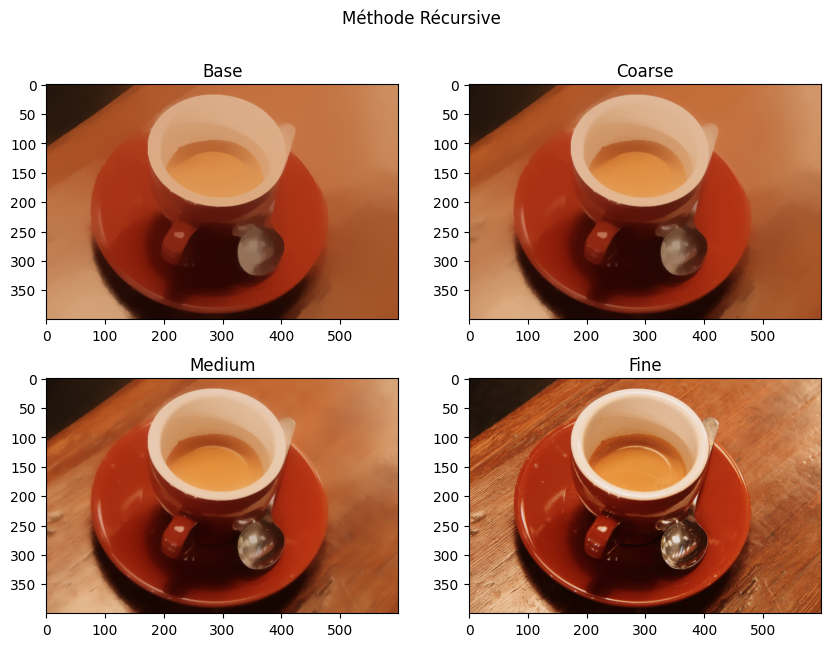

In [16]:
# Affichage d'une méthode
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

axes[0].imshow(base_rec)
axes[0].set_title("Base")
axes[1].imshow(coarse_rec)
axes[1].set_title("Coarse")
axes[2].imshow(medium_rec)
axes[2].set_title("Medium")
axes[3].imshow(fine_rec)
axes[3].set_title("Fine")

fig.suptitle("Méthode Récursive")

Text(0.5, 1.0, 'Image Stylisée')

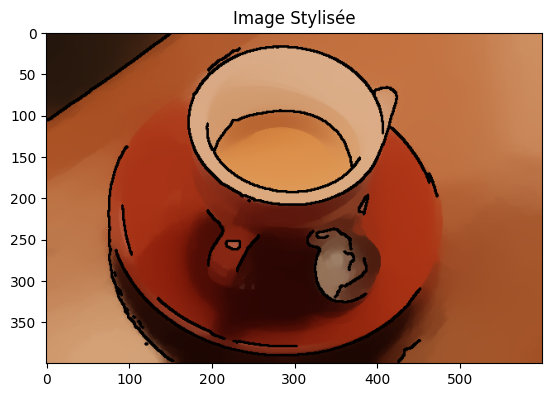

In [17]:
# --- Exemple d'utilisation ---
image_stylisée = toolbox.dessiner_contours_noirs((base_rec*255).astype(np.uint8))
plt.imshow(image_stylisée)
plt.title("Image Stylisée")

## --- PARTIE III : Manipulation Multi-Échelle (Multiscale Tone Manipulation) ---

La manipulation multi-échelle permet de modifier le contraste et les détails d'une image de manière sélective en fonction de leur taille (fréquence spatiale), sans introduire d'artefacts aux frontières des objets.

### Principe de la décomposition :
En faisant varier le paramètre d'échelle $\lambda$ du filtre WLS, nous extrayons trois couches de base de plus en plus lissées ($B_1, B_2, B_3$). Par soustraction successive, nous isolons trois niveaux de détails :
1. **Détails fins :** $I_{\text{orig}} - B_1$
2. **Détails moyens :** $B_1 - B_2$
3. **Détails grossiers :** $B_2 - B_3$

### Formule de recombinaison :
Les couches sont ensuite amplifiées ou atténuées à l'aide de trois coefficients spécifiques ($l_f, l_m, l_c$) avant d'être ré-assemblées à la couche résiduelle la plus grossière ($B_3$) :

$$I_{\text{finale}} = B_3 + l_c \cdot (B_2 - B_3) + l_m \cdot (B_1 - B_2) + l_f \cdot (I_{\text{orig}} - B_1)$$

---

Calcul des couches multi-échelles en cours...


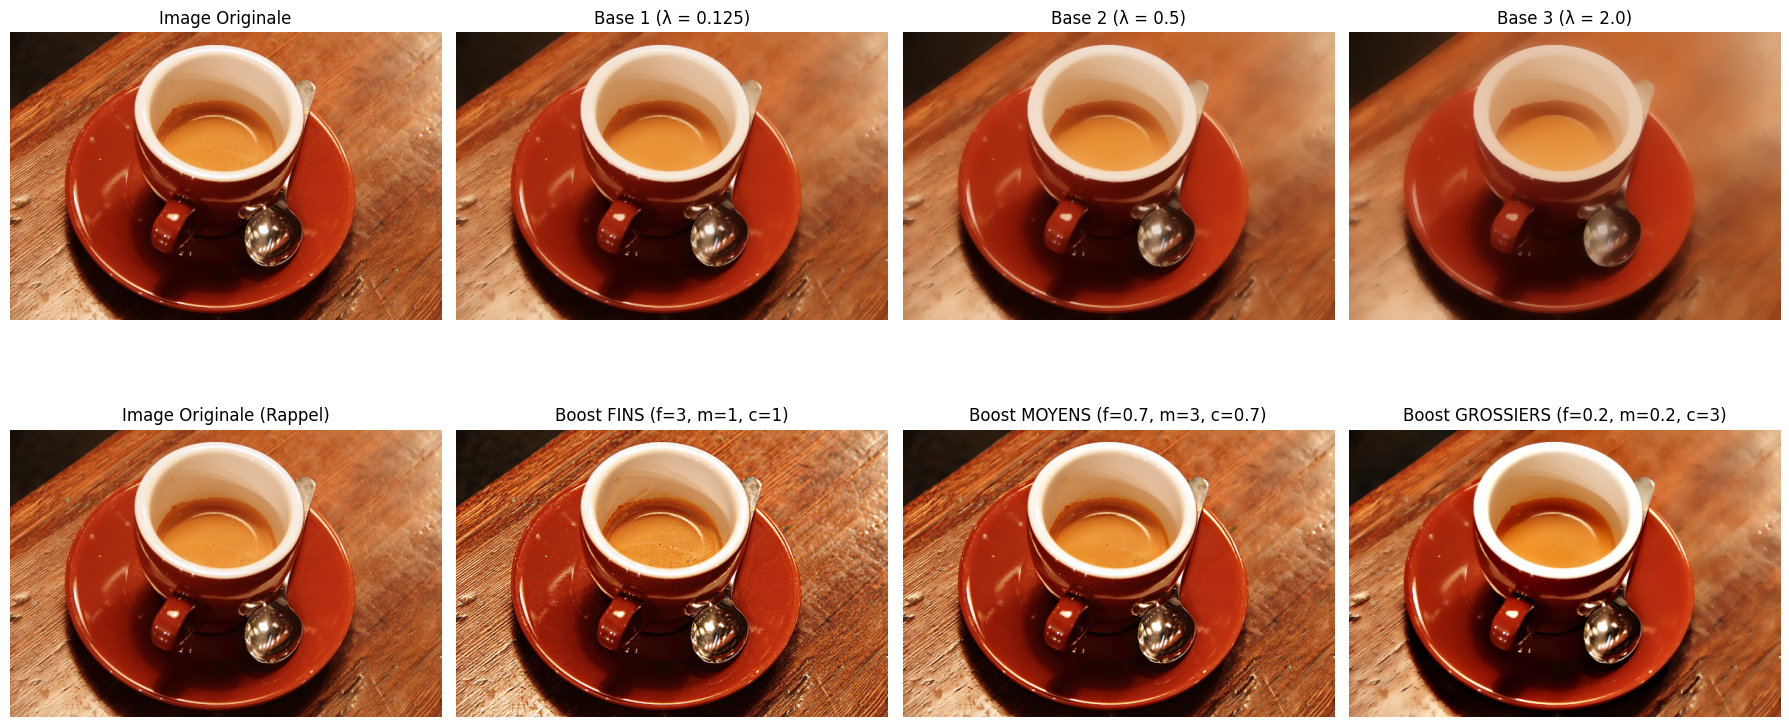

In [18]:
# Méthode itérative

print("Calcul des couches multi-échelles en cours...")

img_test_rgb = image
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

# 1. Calcul des différentes couches de base (du plus fin au plus grossier)
alpha_ms = 1.2
d1 = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=alpha_ms, eps=1e-4, lamb=0.125) # Base 1 : Lissage léger
d2 = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=alpha_ms, eps=1e-4, lamb=0.5)   # Base 2 : Lissage moyen
d3 = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=alpha_ms, eps=1e-4, lamb=2.0)   # Base 3 : Lissage fort

# 2. Génération des 3 manipulations
image_multiscale_f = toolbox.recombine_multiscale(img_test_rgb, d1, d2, d3, lf=3.0, lm=1.0, lc=1.0)
image_multiscale_m = toolbox.recombine_multiscale(img_test_rgb, d1, d2, d3, lf=0.7, lm=3.0, lc=0.7)
image_multiscale_c = toolbox.recombine_multiscale(img_test_rgb, d1, d2, d3, lf=0.2, lm=0.2, lc=3.0)

# 3. Affichage de la grande grille de comparaison
plt.figure(figsize=(18, 9))

# Ligne 1 : Évolution du lissage (Les Couches de Base)
plt.subplot(2, 4, 1)
plt.imshow(img_test_rgb, vmin=0, vmax=1)
plt.title("Image Originale")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(d1, vmin=0, vmax=1)
plt.title("Base 1 (λ = 0.125)")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(d2, vmin=0, vmax=1)
plt.title("Base 2 (λ = 0.5)")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(d3, vmin=0, vmax=1)
plt.title("Base 3 (λ = 2.0)")
plt.axis('off')

# Ligne 2 : Les manipulations de Tone Mapping
plt.subplot(2, 4, 5)
plt.imshow(img_test_rgb, vmin=0, vmax=1)
plt.title("Image Originale (Rappel)")
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(image_multiscale_f, vmin=0, vmax=1)
plt.title("Boost FINS (f=3, m=1, c=1)")
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(image_multiscale_m, vmin=0, vmax=1)
plt.title("Boost MOYENS (f=0.7, m=3, c=0.7)")
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(image_multiscale_c, vmin=0, vmax=1)
plt.title("Boost GROSSIERS (f=0.2, m=0.2, c=3)")
plt.axis('off')

plt.tight_layout()
plt.show()